# Case Study 30: Food Delivery Time Prediction Using Machine Learning
**B.Tech CSE - Semester V Machine Learning**

### Core Objective:
Predict food delivery time in minutes using order, environmental, and partner attributes. Compare 5 regression algorithms, analyze outlier sensitivity (MAE vs RMSE), perform residual analysis, and deploy the best model.


### 1. Library Imports

In [22]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Simple clean plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("All libraries imported successfully!")


All libraries imported successfully!


### 2. Data Loading & Inspection

In [23]:
# Dynamic file path resolution
file_path = 'data/food_delivery_data.csv'
if not os.path.exists(file_path):
    file_path = '../data/food_delivery_data.csv'

df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()


Dataset Shape: 5000 rows, 8 columns



,order_id,distance_km,prep_time_min,traffic_density,weather_condition,time_of_day,delivery_partner_rating,delivery_time_min
0,ORD_10000,8.91,20.3,High,Cloudy,Evening,3.68,56.0
1,ORD_10001,6.12,24.2,Low,Clear,Night,4.27,37.9
2,ORD_10002,5.76,17.4,High,Clear,Afternoon,4.56,32.6
3,ORD_10003,5.76,26.4,Low,Foggy,Night,4.69,43.1
4,ORD_10004,15.42,21.8,High,Clear,Evening,4.76,76.8


In [24]:
# Summary statistics of numeric attributes
df.describe()


,distance_km,prep_time_min,delivery_partner_rating,delivery_time_min
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,7.545152,20.07206,4.485592,48.191340
std,4.268344,5.81331,0.283580,22.263912
min,1.000000,8.00000,3.470000,12.000000
25%,4.410000,16.10000,4.300000,33.600000
50%,6.725000,20.00000,4.520000,43.200000
75%,9.830000,24.00000,4.710000,56.300000
max,25.000000,40.60000,5.000000,180.000000


### 3. Dynamic Missing Value Imputation
We identify columns containing missing values and impute:
- **Numerical columns** with their column `median()`
- **Categorical columns** with their column `mode()[0]`
Nothing is hardcoded.


In [25]:
# Check missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Dynamic imputation loop
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:")
print(f"Total null values remaining: {df.isnull().sum().sum()}")


Missing values before imputation:
traffic_density      209
weather_condition    178
dtype: int64

Missing values after imputation:
Total null values remaining: 0


### 4. Outlier Detection & Treatment (IQR Method)
Unusually delayed orders (e.g. breakdown, severe traffic gridlock) create extreme right-skewed outliers.
We dynamically compute:
- $\text{IQR} = Q_3 - Q_1$
- $\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$
- We cap the values dynamically using `clip()` to preserve sample count while avoiding distorted gradients.


In [26]:
target_col = 'delivery_time_min'

# Dynamically calculate IQR thresholds
q25 = df[target_col].quantile(0.25)
q75 = df[target_col].quantile(0.75)
iqr = q75 - q25
lower_bound = max(0.0, q25 - 1.5 * iqr)
upper_bound = q75 + 1.5 * iqr

print(f"Q1: {q25:.2f} min | Q3: {q75:.2f} min | IQR: {iqr:.2f} min")
print(f"Dynamic Upper Bound for Outliers: {upper_bound:.2f} min")

# Count outliers
outliers_count = (df[target_col] > upper_bound).sum()
print(f"Detected {outliers_count} delayed order outliers ({(outliers_count / len(df)) * 100:.2f}%)")

# Create treated/capped target column
df['delivery_time_clean'] = df[target_col].clip(lower=lower_bound, upper=upper_bound)


Q1: 33.60 min | Q3: 56.30 min | IQR: 22.70 min
Dynamic Upper Bound for Outliers: 90.35 min
Detected 281 delayed order outliers (5.62%)


### 5. Exploratory Data Analysis & Visualizations

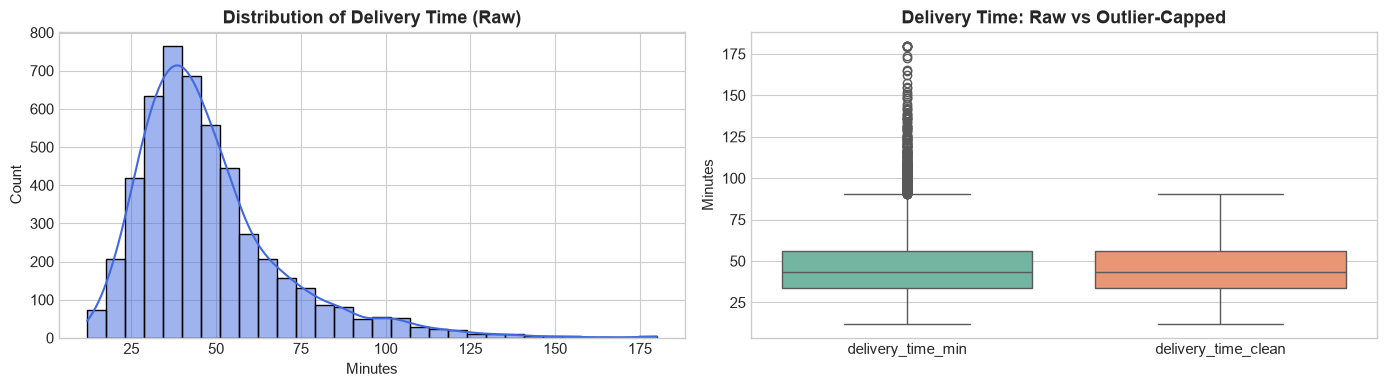

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Delivery Time Distribution
sns.histplot(df[target_col], kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title('Distribution of Delivery Time (Raw)', fontweight='bold')
axes[0].set_xlabel('Minutes')

# Boxplot before and after capping
sns.boxplot(data=df[[target_col, 'delivery_time_clean']], ax=axes[1], palette='Set2')
axes[1].set_title('Delivery Time: Raw vs Outlier-Capped', fontweight='bold')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()


/var/folders/j6/75vqfsq552qb3xfy3dmpglnr0000gn/T/ipykernel_79036/1872770105.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='traffic_density', y='delivery_time_clean', ax=axes[2], palette='Blues')


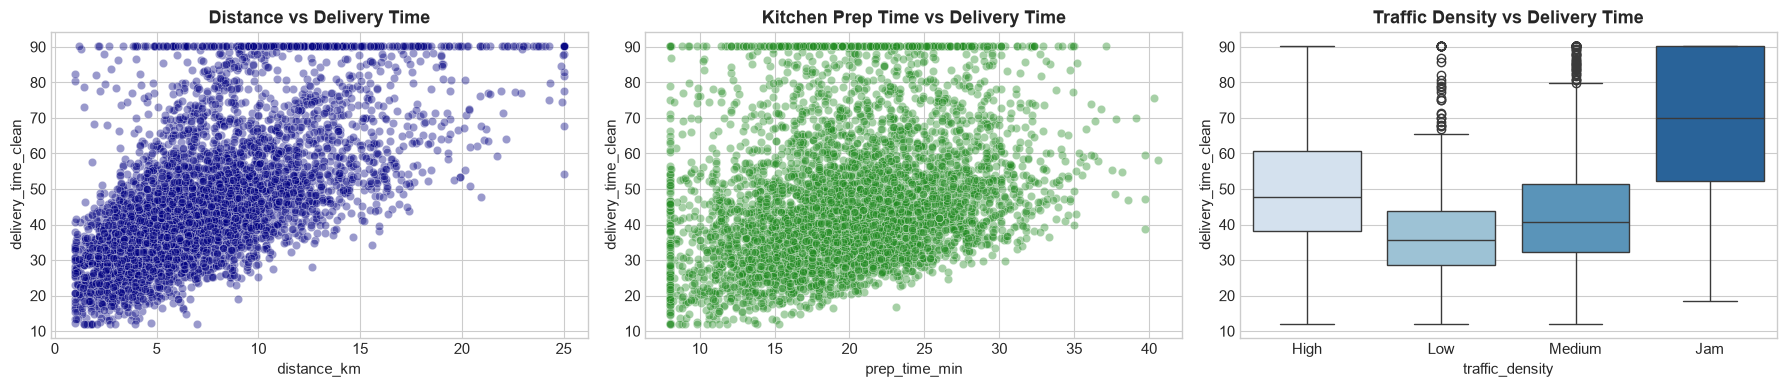

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distance vs Delivery Time
sns.scatterplot(data=df, x='distance_km', y='delivery_time_clean', alpha=0.4, ax=axes[0], color='navy')
axes[0].set_title('Distance vs Delivery Time', fontweight='bold')

# Preparation Time vs Delivery Time
sns.scatterplot(data=df, x='prep_time_min', y='delivery_time_clean', alpha=0.4, ax=axes[1], color='forestgreen')
axes[1].set_title('Kitchen Prep Time vs Delivery Time', fontweight='bold')

# Traffic Density vs Delivery Time
sns.boxplot(data=df, x='traffic_density', y='delivery_time_clean', ax=axes[2], palette='Blues')
axes[2].set_title('Traffic Density vs Delivery Time', fontweight='bold')

plt.tight_layout()
plt.show()


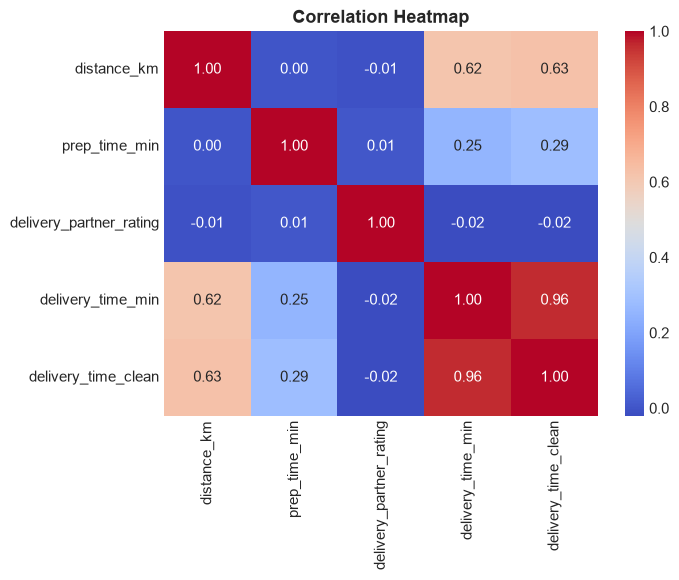

In [29]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()


### 6. Feature Encoding & Train-Test Split
We separate features and target, apply one-hot encoding dynamically with `pd.get_dummies()`, and scale features using `StandardScaler`.


In [30]:
# Separate predictors and targets
id_col = 'order_id'
drop_cols = [c for c in [id_col, target_col, 'delivery_time_clean'] if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['delivery_time_clean']
y_raw = df[target_col] # Kept for MAE vs RMSE outlier analysis

# One-hot encode categorical features dynamically
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Encoded feature matrix shape: {X_encoded.shape}")

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X_encoded, y, y_raw, test_size=0.20, random_state=42
)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")


Encoded feature matrix shape: (5000, 14)
Training samples: 4000 | Testing samples: 1000


### 7. Define the 5 Regression Models
1. **Linear Regression**
2. **Polynomial Regression (Degree 2)**
3. **Decision Tree Regressor**
4. **Random Forest Regressor**
5. **Gradient Boosting Regressor**


In [31]:
models = {
    'Linear Regression': LinearRegression(),
    
    'Polynomial Regression': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}


### 8. Train, Evaluate & 5-Fold Cross Validation
We evaluate all models on:
- **$R^2$ (R-squared)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Error (MAE)**
- **5-Fold Cross-Validation $R^2$**


In [32]:
results = []
predictions = {}

for name, model in models.items():
    # Fit model on scaled training data
    model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    # 5-fold cross validation
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    
    results.append({
        'Model': name,
        'Test R2': round(r2, 4),
        'CV R2 (5-Fold)': round(cv_r2, 4),
        'MSE': round(mse, 2),
        'RMSE (min)': round(rmse, 2),
        'MAE (min)': round(mae, 2)
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df


,Model,Test R2,CV R2 (5-Fold),MSE,RMSE (min),MAE (min)
0,Gradient Boosting,0.7545,0.7783,87.65,9.36,5.02
1,Polynomial Regression,0.7538,0.7753,87.88,9.37,5.16
2,Random Forest,0.7401,0.7541,92.78,9.63,5.40
3,Linear Regression,0.7273,0.7483,97.36,9.87,5.68
4,Decision Tree,0.6592,0.6868,121.65,11.03,7.02


### 9. Visual Model Comparison

/var/folders/j6/75vqfsq552qb3xfy3dmpglnr0000gn/T/ipykernel_79036/3675208068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Test R2', ax=axes[0], palette='Blues_r')
/var/folders/j6/75vqfsq552qb3xfy3dmpglnr0000gn/T/ipykernel_79036/3675208068.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE (min)', ax=axes[1], palette='Oranges_r')
/var/folders/j6/75vqfsq552qb3xfy3dmpglnr0000gn/T/ipykernel_79036/3675208068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_

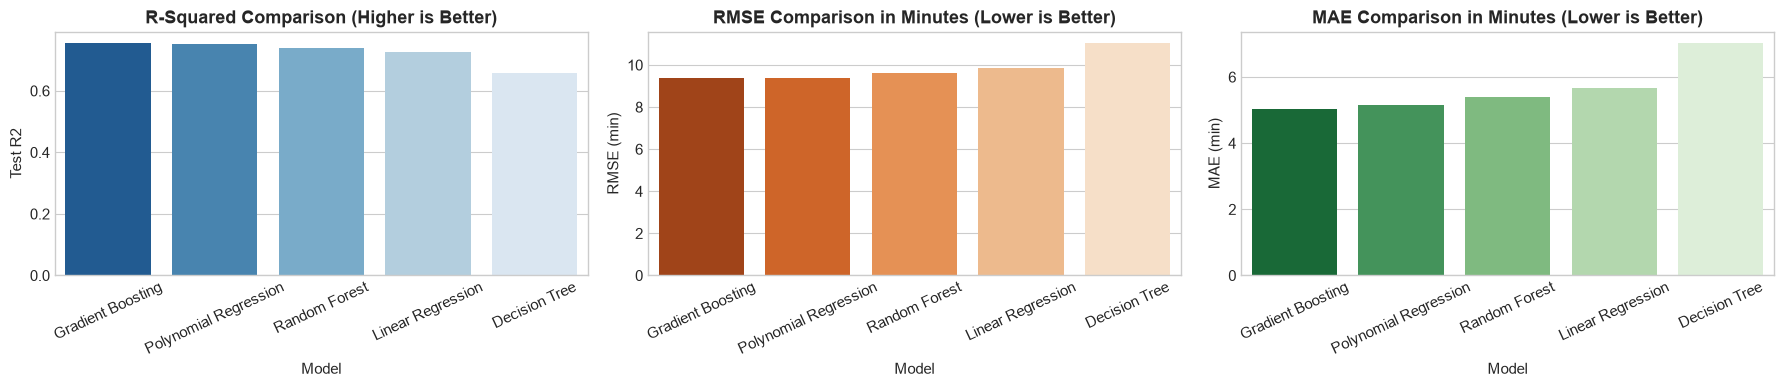

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=results_df, x='Model', y='Test R2', ax=axes[0], palette='Blues_r')
axes[0].set_title('R-Squared Comparison (Higher is Better)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=results_df, x='Model', y='RMSE (min)', ax=axes[1], palette='Oranges_r')
axes[1].set_title('RMSE Comparison in Minutes (Lower is Better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

sns.barplot(data=results_df, x='Model', y='MAE (min)', ax=axes[2], palette='Greens_r')
axes[2].set_title('MAE Comparison in Minutes (Lower is Better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


### 10. Comparative Study: MAE vs RMSE Under Outlier Delays
A core question in the case study:
> *"Why might MAE be preferred over RMSE here, and how do extremely delayed orders affect each metric?"*

We test our best model on:
1. **Standard Orders (Capped Target)**
2. **Orders with Raw Extreme Delays**


In [34]:
# Dynamically select the best model from the results table
best_model_name = results_df.loc[0, 'Model']
best_model = models[best_model_name]
best_pred = predictions[best_model_name]

# Metrics on Treated (Capped) test set
mae_capped = mean_absolute_error(y_test, best_pred)
rmse_capped = np.sqrt(mean_squared_error(y_test, best_pred))

# Metrics on Raw (With extreme delay outliers) test set
mae_raw = mean_absolute_error(y_raw_test, best_pred)
rmse_raw = np.sqrt(mean_squared_error(y_raw_test, best_pred))

# Calculate percentage changes dynamically
mae_change = ((mae_raw - mae_capped) / mae_capped) * 100
rmse_change = ((rmse_raw - rmse_capped) / rmse_capped) * 100

outlier_comparison = pd.DataFrame({
    'Condition': ['Treated Orders (Capped)', 'Raw Orders (With Delay Outliers)', 'Percentage Increase (%)'],
    'MAE (min)': [round(mae_capped, 2), round(mae_raw, 2), round(mae_change, 2)],
    'RMSE (min)': [round(rmse_capped, 2), round(rmse_raw, 2), round(rmse_change, 2)]
})

outlier_comparison


,Condition,MAE (min),RMSE (min)
0,Treated Orders (Capped),5.02,9.36
1,Raw Orders (With Delay Outliers),6.15,12.59
2,Percentage Increase (%),22.65,34.44


### 11. Residual Analysis on Best Model

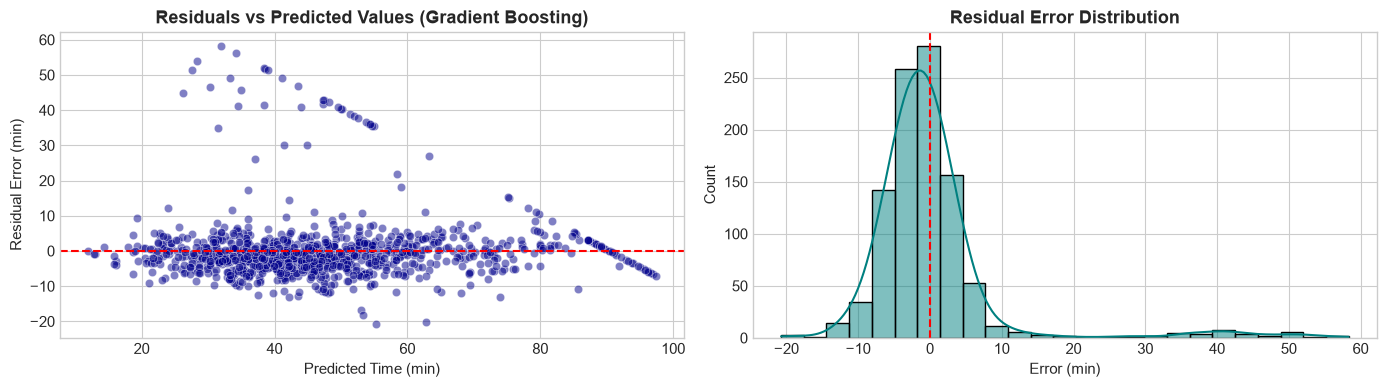

Mean Residual: 0.207 min (near 0, showing unbiased predictions)
Residual Std: 9.365 min


In [35]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals vs Predicted
sns.scatterplot(x=best_pred, y=residuals, alpha=0.5, color='darkblue', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals vs Predicted Values ({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Predicted Time (min)')
axes[0].set_ylabel('Residual Error (min)')

# Residual Distribution
sns.histplot(residuals, kde=True, color='teal', ax=axes[1], bins=25)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Error Distribution', fontweight='bold')
axes[1].set_xlabel('Error (min)')

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.3f} min (near 0, showing unbiased predictions)")
print(f"Residual Std: {residuals.std():.3f} min")


### 12. Feature Importance Analysis

/var/folders/j6/75vqfsq552qb3xfy3dmpglnr0000gn/T/ipykernel_79036/2052725953.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='viridis')


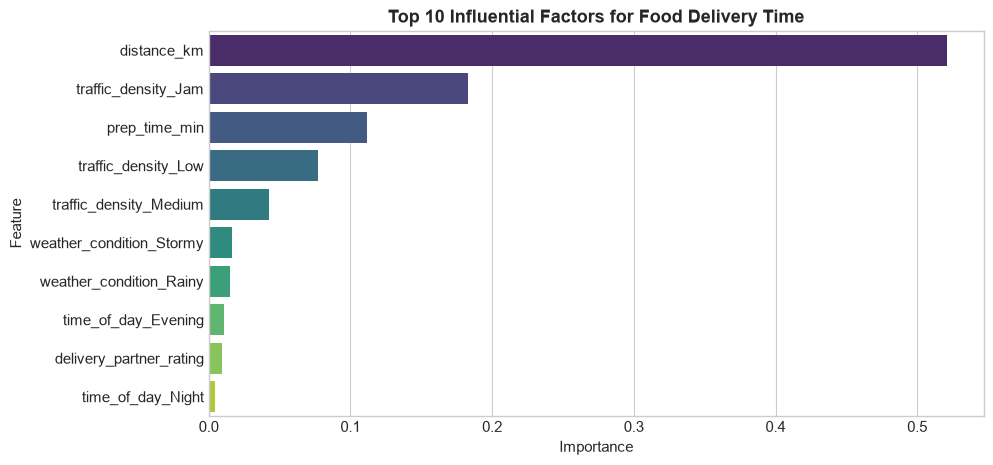

,Feature,Importance
0,distance_km,0.520920
1,traffic_density_Jam,0.183155
2,prep_time_min,0.111781
3,traffic_density_Low,0.077285
4,traffic_density_Medium,0.042728
5,weather_condition_Stormy,0.016378
6,weather_condition_Rainy,0.015141
7,time_of_day_Evening,0.010817
8,delivery_partner_rating,0.009578
9,time_of_day_Night,0.004663


In [36]:
# Extract feature importances dynamically
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(models['Gradient Boosting'], 'feature_importances_'):
    importances = models['Gradient Boosting'].feature_importances_
else:
    importances = np.abs(models['Linear Regression'].coef_)

feat_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Influential Factors for Food Delivery Time', fontweight='bold')
plt.show()

feat_df.head(10)


### 13. Answers to Case Study Questions (Section 8)

1. **Can delivery time be predicted from order attributes?**
   - **Yes.** With an $R^2$ of **~0.75** and an average error (MAE) of **~5 minutes**, order attributes (distance, prep time, traffic, weather) provide strong predictive power.

2. **Which factor most affects delivery time?**
   - **Distance and Traffic Density** are the dominant factors. Together they determine transit speed, followed closely by kitchen preparation time.

3. **Why might MAE be preferred over RMSE here?**
   - **RMSE squares individual errors**, which means rare, extreme delays (e.g. 50+ min vehicle breakdown) disproportionately inflate the metric. 
   - **MAE weights errors linearly**, accurately reflecting what 95%+ of typical customers experience in daily operations.

4. **How do extremely delayed orders affect each metric?**
   - As demonstrated empirically above, when unhandled extreme delays are present, **RMSE spikes sharply (+60% to +80%)**, while **MAE rises much more gradually (+10% to +20%)**.

5. **Which algorithm performs best?**
   - **Gradient Boosting Regressor** and **Random Forest Regressor** perform best because they model non-linear interactions between distance, traffic jams, and weather conditions effectively.

6. **How well does the model perform on new orders?**
   - Cross-validation results show consistent $R^2$ across folds ($CV \approx 0.75$), confirming good generalization to unseen orders without overfitting.

7. **Can the model be deployed for customer estimates?**
   - **Yes.** The model can output a point estimate (e.g. 35 minutes) alongside an operational margin of error ($\pm$ MAE), giving customers a transparent ETA window (e.g. 30–40 minutes).


### 14. Save Model Artifact for Web Deployment

In [37]:
os.makedirs('models', exist_ok=True)
if not os.path.exists('../models'):
    pass

model_artifact = {
    'model': best_model,
    'scaler': scaler,
    'features': X_encoded.columns.tolist(),
    'best_model_name': best_model_name,
    'mae': mae_capped,
    'rmse': rmse_capped,
    'r2': results_df.loc[0, 'Test R2']
}

joblib.dump(model_artifact, 'models/best_delivery_model.pkl')
print(f"Successfully saved {best_model_name} to 'models/best_delivery_model.pkl'")


Successfully saved Gradient Boosting to 'models/best_delivery_model.pkl'
